In [1]:
###################################
# Plot paper4 figures
# 2024.8.2 originally written, updated on 2024.9.20
# Mu-Ting Chien
##############################

In [2]:
import os
import sys
sys.path.append('/glade/work/muting/function/')
#import KW_diagnostics as KW
import mjo_mean_state_diagnostics as MJO
import numpy as np
import matplotlib.pyplot as plt
import os

In [83]:
dir_out            = '/glade/work/muting/KW/'
CASENAME_LIST2     = list(['SST_AQP3_Qobs_27_-4K',\
                          'SST_AQP3_Qobs_27',\
                          'SST_AQP3_Qobs_27_4K'])
CASENAME_LONG_LIST  = list(['3h_20y_CLUBB_new','3h_20y_CLUBB_new_uv_tendency','3h_20y_CLUBB_new'])
#figdir = dir_out+'figure/Post_general/Paper4/' #original directory
figdir = dir_out+'figure/Post_general/Paper4_20260122_noctl/' #updated directory
figdir_supplement = figdir+'Supplement/'
os.makedirs(figdir, exist_ok=True)
os.makedirs(figdir_supplement, exist_ok=True) 

#output_dir_all          = dir_out+'output_data/Paper4/' # original directory
#output_dir_all_3yr = dir_out+'output_data/All_3hr_3yr/' # original directory
output_dir_all          = dir_out+'output_data/Paper4_20240822/' # updated directory

#os.makedirs(figdir+'test/', exist_ok=True)
V2_name = list(['pr_kwproj_ano','PC1_Q'])
V1_short = list(['qv','T'])
V2_short = list(['pr','PCQ1'])
NUDGE_LIST = list(['3h_20y_CLUBB_new','3h_20y_CLUBB_new_uv_tendency','3h_20y_CLUBB_new'])
color_list = list(['darkblue','green','orangered'])

In [4]:
import os
import sys
sys.path.append('/glade/work/muting/function/')
#import KW_diagnostics as KW
#import mjo_mean_state_diagnostics as MJO
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load correlation coefficient between T and precip, q and precip (Fig. 2)
save_corr_q_PCQ1 = 1
if save_corr_q_PCQ1 == 0:
    for n1 in range(0, np.size(V1_short)):
        for n2 in range(1, np.size(V2_short)):
            for icase in range(0, 3):
                CASENAME       = CASENAME_LIST2[icase]+'_'+NUDGE_LIST[icase]
                output_dir     = dir_out+'output_data/'+CASENAME+'/'
                data = np.load(output_dir+'corrcoef_'+V1_short[n1]+'_'+V2_short[n2]+'_level.npz')
                if icase == 0:
                    plev_r = data['plev']
                    nlev_r = np.size(plev_r)
                    if n1 == 0:
                        r_q = np.empty([nlev_r, 3])
                    elif n1 == 1:
                        r_T = np.empty([nlev_r, 3])
                if n1 == 0:
                    r_q[:,icase] = data['r']
                elif n1 == 1:
                    r_T[:,icase] = data['r']
    
    np.savez(output_dir_all+'Corrcoef_PCQ1_q_T.npz', r_PCQ1_q=r_q, r_PCQ1_T=r_T, plev=plev_r)
else:
    data = np.load(output_dir_all+'Corrcoef_PCQ1_q_T.npz')
    r_q = data['r_PCQ1_q']
    r_T = data['r_PCQ1_T']

In [6]:
# Load EOF profile (Fig. 2)
save_eof = 0
if save_eof == 0:
    for icase in range(0,3):
        CASENAME       = CASENAME_LIST2[icase]+'_'+NUDGE_LIST[icase]
        output_dir     = dir_out+'output_data/'+CASENAME+'/'
        data = np.load(output_dir+'EOF.npz')
        plev = data['plev']
        #plev = plev[ilevmin:ilevmax+1]
        nlev = np.size(plev)
        if icase == 0:
            EOF1 = np.empty([nlev, 3])
            EOF2 = np.empty([nlev, 3])
        EOF1[:,icase] = data['R_EOF1_smooth'][:]#[ilevmin:ilevmax+1]
        EOF2[:,icase] = data['R_EOF2_smooth'][:]#[ilevmin:ilevmax+1]
    
    np.savez(output_dir_all+'EOF_all.npz', EOFQ1=EOF1, EOFQ2=EOF2, plev=plev)
else:
    data = np.load(output_dir_all+'EOF_all.npz')
    EOF1 = data['EOFQ1']
    EOF2 = data['EOFQ2']
    plev = data['plev']

In [7]:
# Load relative magnitude for KW composite (Fig. 11)
data = np.load(output_dir_all+'Coupling_relative_magnitude_each_process.npz') # originally in output_dir_3yr directory
qlf_KW_mag_rel       = data['qlf_KW_mag_rel']
wdqdp_lf_KW_mag_rel  = data['wdqdp_lf_KW_mag_rel']
w_lf_KW_mag_rel      = data['w_lf_KW_mag_rel']
T2_lf_KW_mag_rel     = data['T2_lf_KW_mag_rel']
ZMMU_lf_KW_mag_rel   = data['ZMMU_lf_KW_mag_rel']
Q_lf_KW_mag_rel      = data['Q_lf_KW_mag_rel']

In [8]:
#############################
# Load data for Fig. 12
####################################
save_pr_var = 1
if save_pr_var == 0:
    # Load variance of precip anomaly
    for icase in range(0, 3):
        CASENAME       = CASENAME_LIST2[icase]+'_'+CASENAME_LONG_LIST[icase]
        output_dir     = dir_out+'output_data/'+CASENAME+'/'
        # Load precip ano
        data          = np.load(output_dir+'precip_kw.npz')
        pr_ano        = data['pr_kwproj_ano_short'] # This is anomaly without 10-day low pass variabiltiy
        if icase == 0:
            pr_var = np.empty([3])
        pr_var[icase] = np.var(pr_ano)
    np.savez(output_dir_all+'Precip_kwproj_anomaly_variance.npz',pr_var=pr_var)
else:
    data = np.load(output_dir_all+'Precip_kwproj_anomaly_variance.npz')
    pr_var = data['pr_var']


# Load lag-plev regression 
data = np.load(output_dir_all+'DT_decomp_lag_plev.npz')
Qcond_lag_plev    = data['Qcond_lag_plev']
Q_ZM_lag_plev     = data['Q_ZM_lag_plev']
Q_CLUBB_lag_plev  = data['Q_CLUBB_lag_plev']
Q_MP_lag_plev     = data['Q_MP_lag_plev']
EVAPT_ZM_lag_plev = data['EVAPT_ZM_lag_plev']
xx   = data['xx']
yy   = data['yy']
lags = data['lags']
plev = data['plev']


# Load melting
data = np.load(output_dir_all+'ZM_MP_lag_plev.npz')
MELTSDT_lag_plev = data['MELTSDT_lag_plev']

In [51]:
print(output_dir_all)

/glade/work/muting/KW/output_data/Paper4_20240822/


In [48]:
# Load lag-plev regression projected onto EOF2 (Fig. 13)
data = np.load(output_dir_all+'DT_decomp_lag_plev_project-to-EOF.npz')
Q_ZM_lag_plev_EOF1     = data['Q_ZM_lag_plev_EOF1']
EVAPT_ZM_lag_plev_EOF1 = data['EVAPT_ZM_lag_plev_EOF1']
Q_CLUBB_lag_plev_EOF1  = data['Q_CLUBB_lag_plev_EOF1']
Q_MP_lag_plev_EOF1     = data['Q_MP_lag_plev_EOF1']
#
Q_ZM_lag_plev_EOF2     = data['Q_ZM_lag_plev_EOF2']
EVAPT_ZM_lag_plev_EOF2 = data['EVAPT_ZM_lag_plev_EOF2']
Q_CLUBB_lag_plev_EOF2  = data['Q_CLUBB_lag_plev_EOF2']
Q_MP_lag_plev_EOF2     = data['Q_MP_lag_plev_EOF2']
#
plev                   = data['plev']
lags                   = data['lags']

In [72]:
data = np.load(output_dir_all+'DT_decomp_lag_plev_project-to-EOF.npz')
lags  = data['lags']
ilag0 = np.argwhere(lags==0).squeeze()
Q_ZM_lag_plev_EOF1_lag0_NEW     = data['Q_ZM_lag_plev_EOF1'][ilag0,:]
EVAPT_ZM_lag_plev_EOF1_lag0_NEW = data['EVAPT_ZM_lag_plev_EOF1'][ilag0,:]
Q_CLUBB_lag_plev_EOF1_lag0_NEW  = data['Q_CLUBB_lag_plev_EOF1'][ilag0,:]
Q_MP_lag_plev_EOF1_lag0_NEW     = data['Q_MP_lag_plev_EOF1'][ilag0,:]
Q_MELT_lag_plev_EOF1_lag0_NEW   = data['Q_MELT_lag_plev_EOF1'][ilag0,:]
#
Q_ZM_lag_plev_EOF2_lag0_NEW     = data['Q_ZM_lag_plev_EOF2'][ilag0,:]
EVAPT_ZM_lag_plev_EOF2_lag0_NEW = data['EVAPT_ZM_lag_plev_EOF2'][ilag0,:]
Q_CLUBB_lag_plev_EOF2_lag0_NEW  = data['Q_CLUBB_lag_plev_EOF2'][ilag0,:]
Q_MP_lag_plev_EOF2_lag0_NEW     = data['Q_MP_lag_plev_EOF2'][ilag0,:]
Q_MELT_lag_plev_EOF2_lag0_NEW   = data['Q_MELT_lag_plev_EOF2'][ilag0,:]
#
plev                   = data['plev']

In [11]:
###############################
# Load data for Fig. 13 and 14 (CLUBB, MP vertical structure, EOF2, Tmean)
############################
save_melting_level = 0
if save_melting_level == 0:
    # 1. load mean state T
    for icase in range(0,3):
        if icase != 1:
            CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new'
        else:
            CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new_uv_tendency'
        output_dir = dir_out+'output_data/'+CASENAME+'/'
        data = np.load(output_dir+'QTUVZq.npz')
        plev_m = data['plev']
        nlev = np.size(plev_m)
        if icase == 0:
            Tm = np.empty([nlev, 3])
        Tm[:,icase] = data['Tm']-273.15
    
    # 2. Find melting level
    for icase in range(0,3):
        if icase == 0:
            ilev_melt = np.zeros([3]).astype('int')
        ilev_melt[icase] = int(np.argwhere(np.abs(Tm[:,icase])==np.min(np.abs(Tm[:,icase]))).squeeze())

    # Save output
    np.savez(output_dir_all+'Tm_melting_level.npz', Tm=Tm, plev = plev, ilev_melt=ilev_melt, plev_melt=plev_m[ilev_melt])
else:
    data = np.load(output_dir_all+'Tm_melting_level.npz')
    Tm = data['Tm']
    plev_m = data['plev']
    ilev_melt = data['ilev_melt']
print(plev_m[ilev_melt])

# 3. Load vertical structure of lag-regression (CLUBB, MP)
data = np.load(output_dir_all+'DT_decomp_lag_plev.npz')
lags = data['lags']
ilag0 = np.argwhere(lags==0).squeeze()
Qcond_lag0_plev    = data['Qcond_lag_plev'][ilag0,:,:]
Q_ZM_lag0_plev     = data['Q_ZM_lag_plev'][ilag0,:,:]
Q_CLUBB_lag0_plev  = data['Q_CLUBB_lag_plev'][ilag0,:,:]
Q_MP_lag0_plev     = data['Q_MP_lag_plev'][ilag0,:,:]

MELTSDT_lag0_plev = MELTSDT_lag_plev[ilag0,:,:]
#EVAPT_ZM_lag0_plev = data['EVAPT_ZM_lag_plev']
xx   = data['xx']
yy   = data['yy']
plev = data['plev']

[650 575 525]


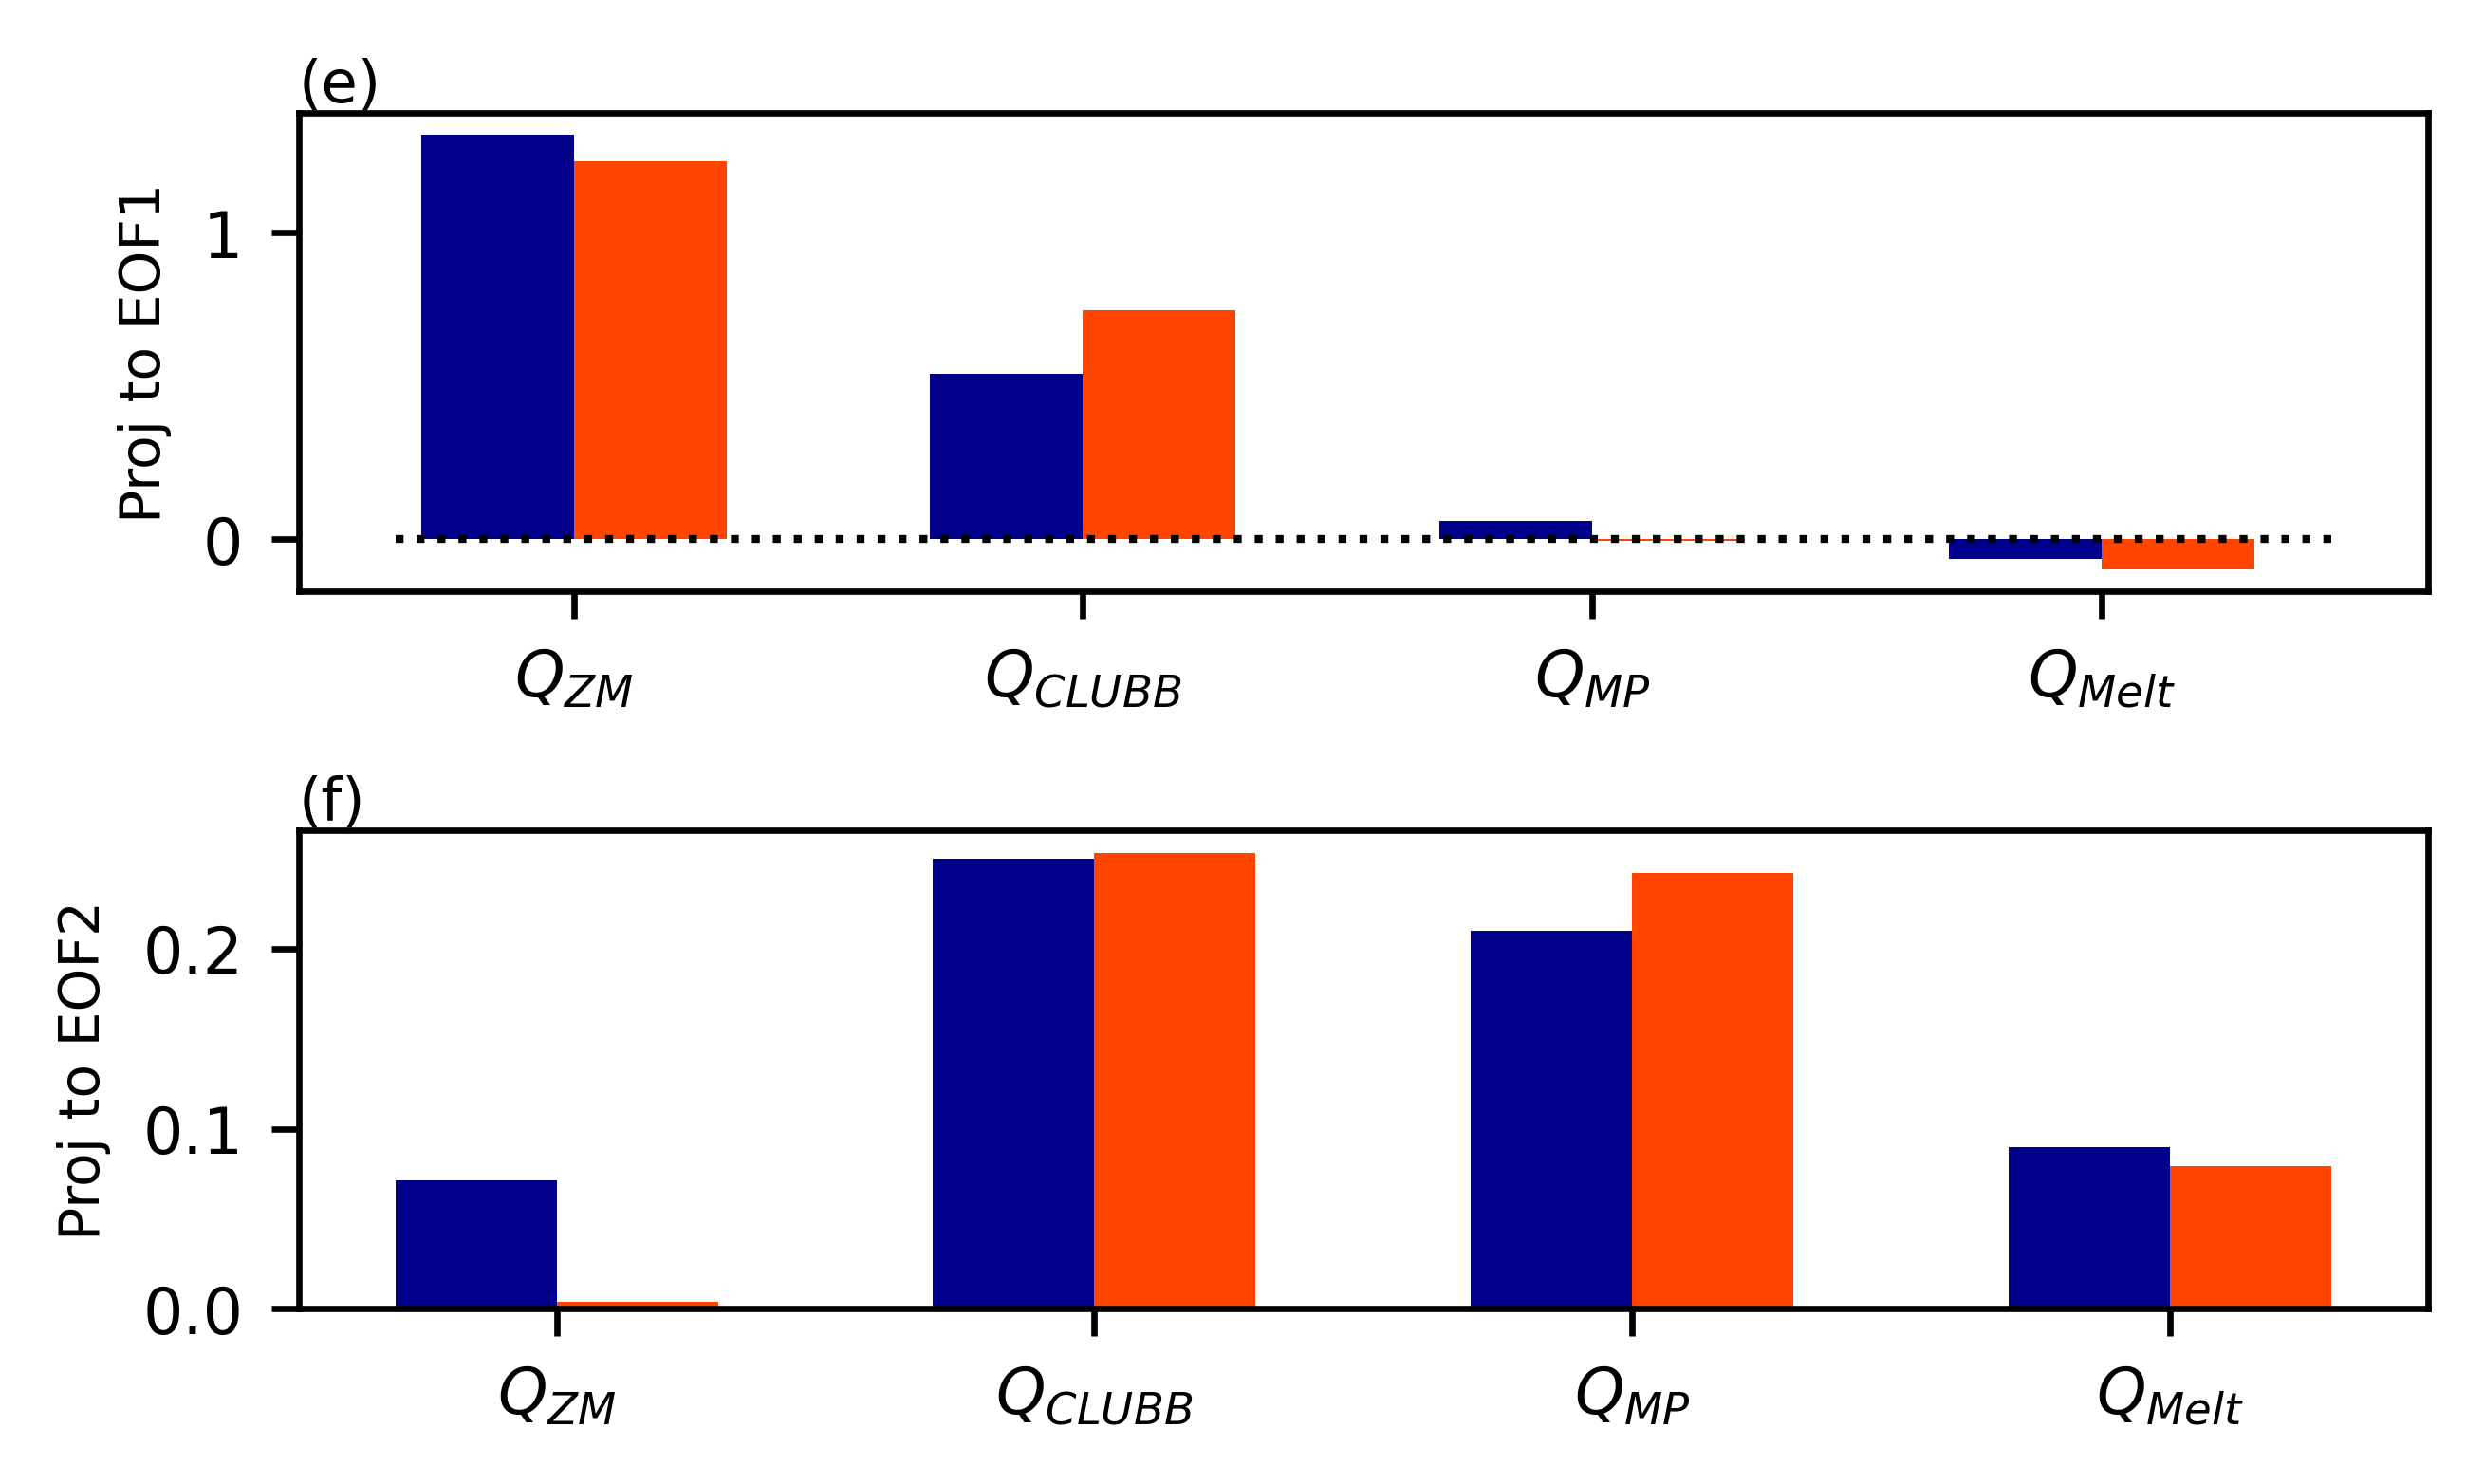

In [92]:
##########################################
# Fig. 13: PLot timeseries of each term projected onto EOF2
###########################################

font = 8
zero = np.zeros([np.size(lags)])

cont_EOF1 = np.array([Q_ZM_lag_plev_EOF1_lag0_NEW, Q_CLUBB_lag_plev_EOF1_lag0_NEW,\
                      Q_MP_lag_plev_EOF1_lag0_NEW, Q_MELT_lag_plev_EOF1_lag0_NEW])
cont_EOF2 = np.array([Q_ZM_lag_plev_EOF2_lag0_NEW, Q_CLUBB_lag_plev_EOF2_lag0_NEW,\
                      Q_MP_lag_plev_EOF2_lag0_NEW, Q_MELT_lag_plev_EOF2_lag0_NEW])

plt_list = list([0, np.nan, 1])

fig,axes = plt.subplots(2,1,figsize=(5.5, 3),dpi=600)
plt.subplots_adjust(left=0.1,right=0.78,top=0.9,bottom=0.2,wspace=0.2, hspace = 0.5)
plt.rcParams.update({'font.size': font})
plt.subplot(2,1,1)
for icase in range(0, 3):
    if icase == 1:
        continue
    plt.bar( np.arange(0,4)+0.3*plt_list[icase], cont_EOF1[:,icase], color=color_list[icase], width=0.3)
plt.plot( [-0.2,3.6], [0, 0], 'k:', linewidth=1)
plt.xticks(np.arange(0,4)+0.15, ('$Q_{ZM}$','$Q_{CLUBB}$','$Q_{MP}$','$Q_{Melt}$'))
plt.ylabel('Proj to EOF1', fontsize=7)
plt.title('(e)', loc='left', pad=1, fontsize=7.5)

plt.subplot(2, 1, 2)
for icase in range(0, 3):
    if icase == 1:
        continue
    plt.bar( np.arange(0,4)+0.3*plt_list[icase], cont_EOF2[:,icase], color=color_list[icase], width=0.3)
plt.xticks(np.arange(0,4)+0.15, ('$Q_{ZM}$','$Q_{CLUBB}$','$Q_{MP}$','$Q_{Melt}$'))
plt.ylabel('Proj to EOF2', fontsize=7)
plt.title('(f)', loc='left', pad=1,fontsize=7.5)

        
plt.savefig(figdir+'Fig.4_low_contribution_to_EOF1_2_with-melt.png',dpi=600)  
plt.show()

[650 575 525]


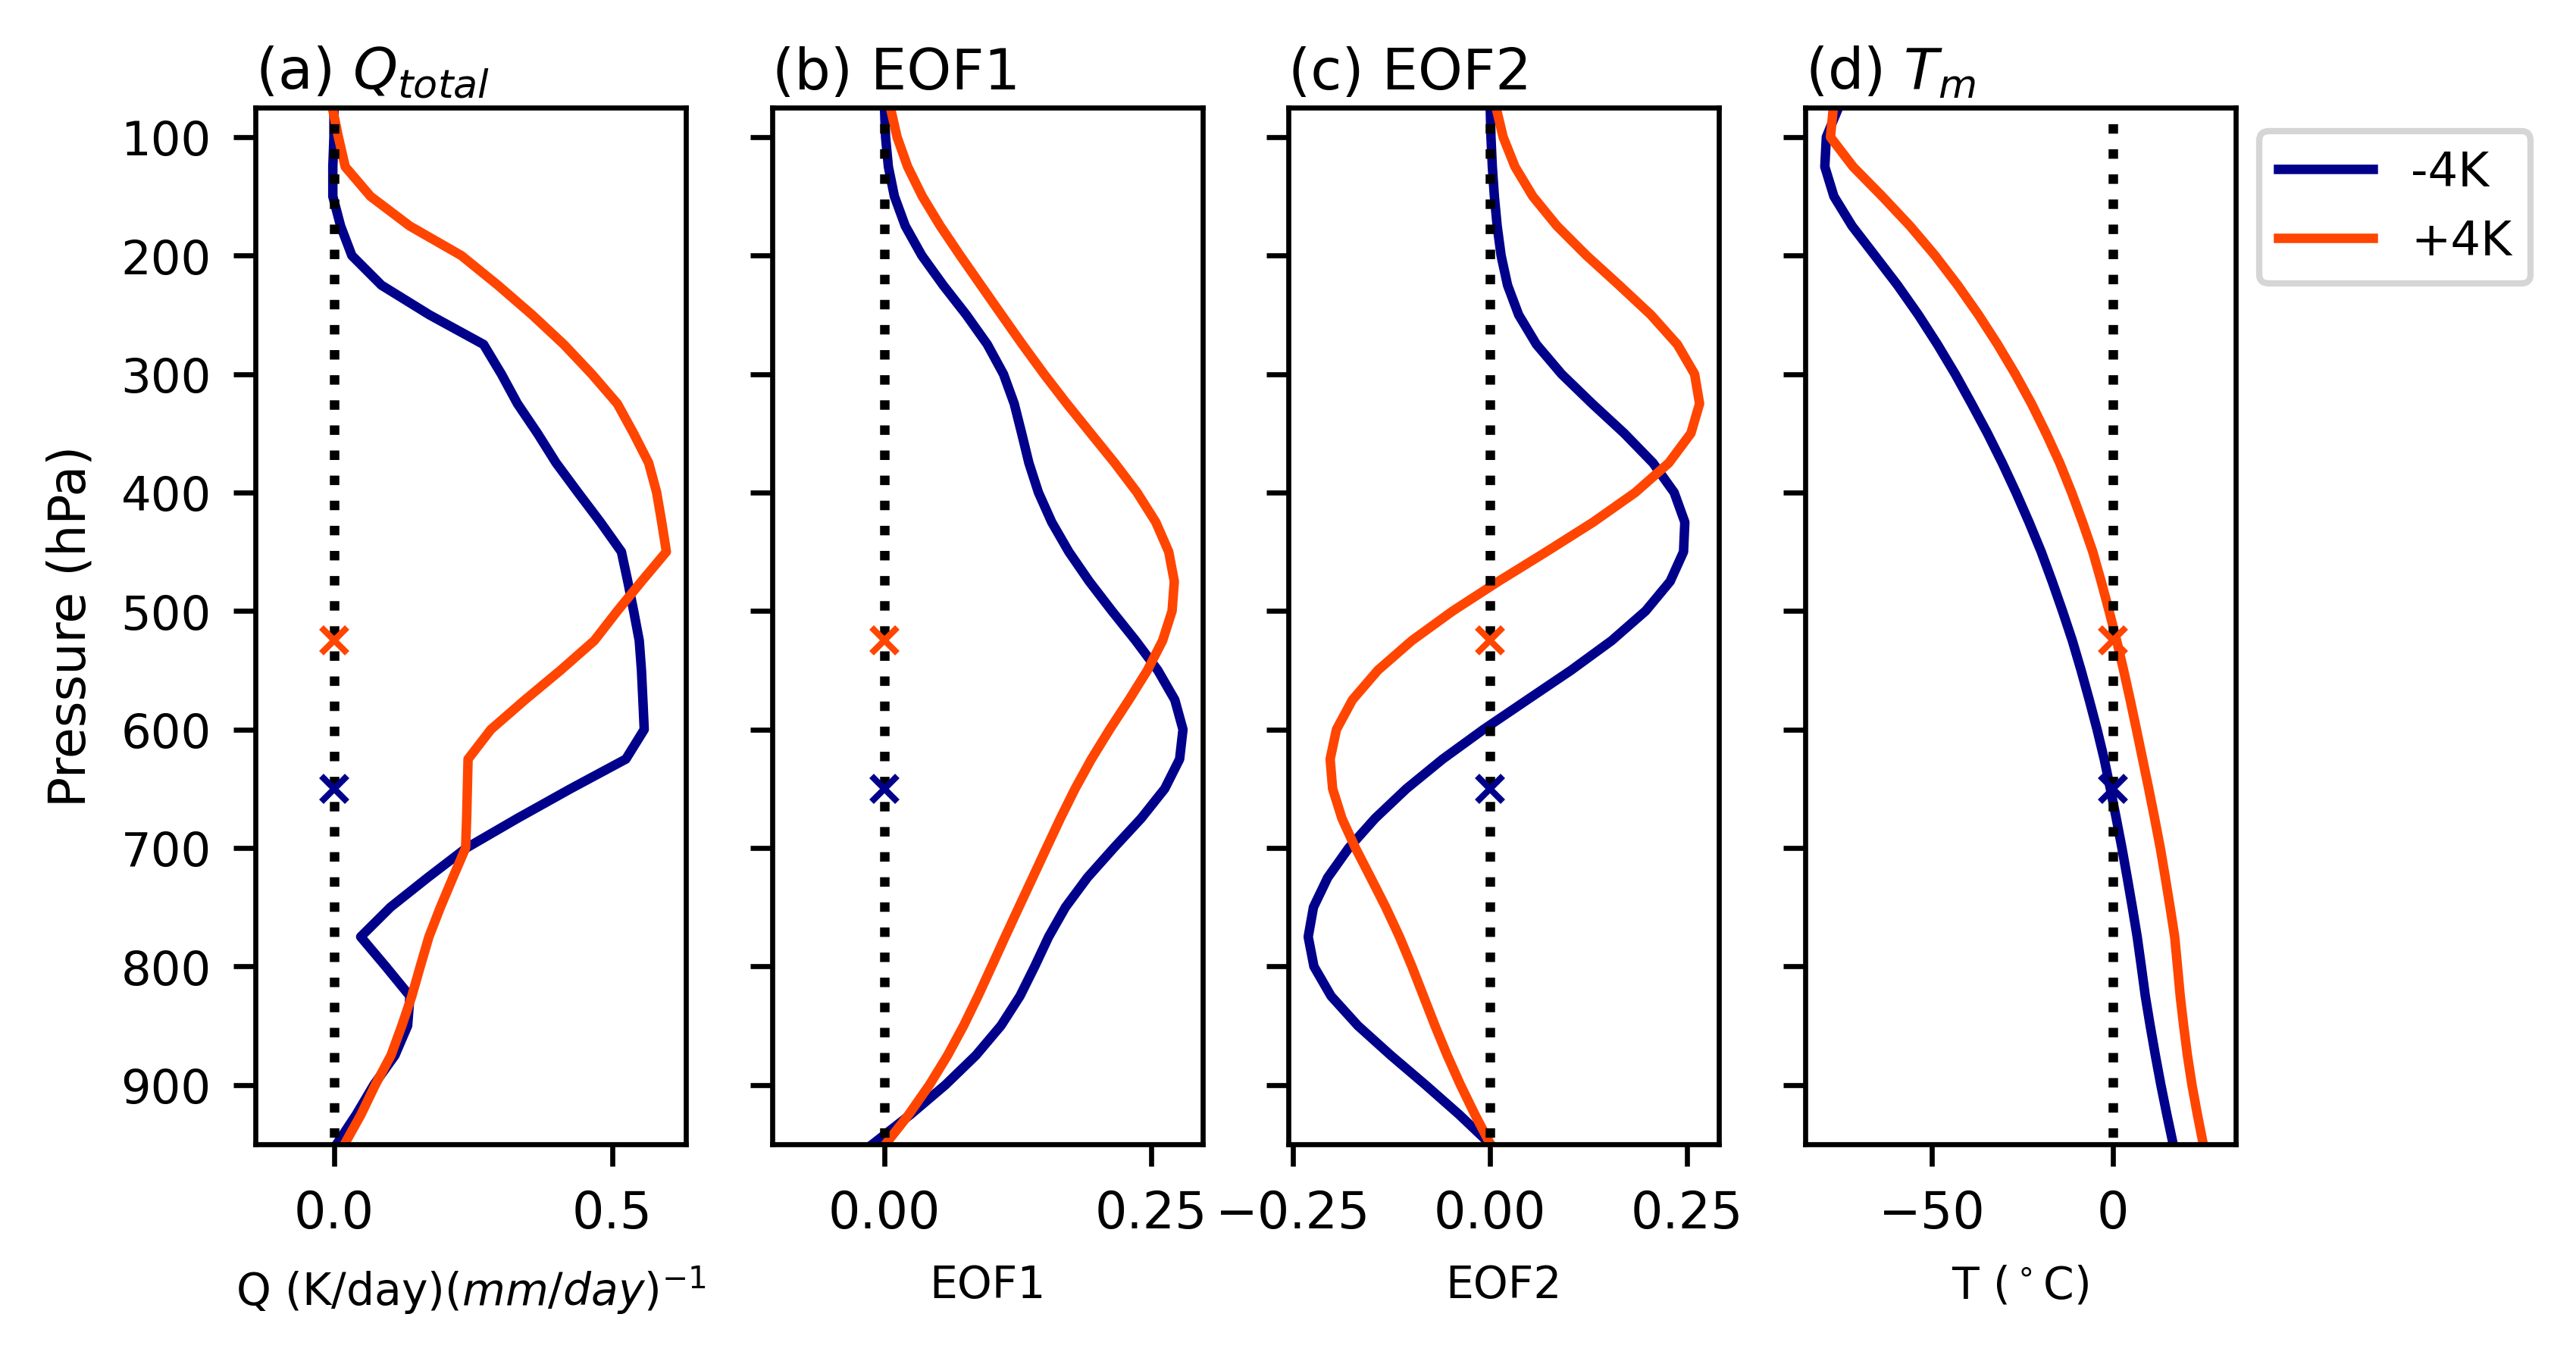

In [85]:
###############################
# Fig. 14: Plot 4 figures together
################################
mark_melting_level=1
for icase in range(0,3):
    if icase == 0:
        ilev_melt = np.zeros([3]).astype('int')
    ilev_melt[icase] = int(np.argwhere(np.abs(Tm[:,icase])==np.min(np.abs(Tm[:,icase]))).squeeze())
print(plev_m[ilev_melt])

title = list(['(a) $Q_{total}$','(b) EOF1','(c) EOF2','(d) $T_{m}$'])
#'(b) $Q_{MP}$' $Q_{CLUBB}$
#'Q_CLUBB_lag0_plev','Q_MP_lag0_plev',
xlabel_list = list(['Q (K/day)$(mm/day)^{-1}$','EOF1','EOF2','T ($^\circ$C)'])
font = 8
fig,axes = plt.subplots(1,4,figsize=(6.5, 3),dpi=600)
plt.subplots_adjust(left=0.15,right=0.82,top=0.91,bottom=0.15,wspace=0.2)
plt.rcParams.update({'font.size': font})
zero = np.zeros([nlev])
vname = list(['Qcond_lag0_plev','EOF1','EOF2','Tm'])#'Tm_10SN'])
for iplt in range(0,4):
    plt.subplot(1,4,iplt+1)
    ax = plt.gca()
    V = globals()[vname[iplt]]
    if iplt == 0:
        V = V/pr_var

    for icase in range(0,3):
        if icase == 1:
            continue
        plt.plot(V[:,icase], plev, color=color_list[icase])

    plt.plot(zero, plev,'k:')
    plt.tick_params(bottom=True,top=False,left=True,right=False)
    plt.ylim([75, 950]) 
    plt.yticks(np.arange(100,1000,100),fontsize=7.5)
    if iplt == 3:
        #ax.legend(['-4K','CTL','+4K'],bbox_to_anchor=(1, 1), loc='upper left',fontsize=7.5)
        ax.legend(['-4K','+4K'],bbox_to_anchor=(1, 1), loc='upper left',fontsize=7.5)
    plt.gca().invert_yaxis()
    plt.title(title[iplt], pad=3, loc='left',fontsize=9)
    if iplt == 0:
        plt.ylabel('Pressure (hPa)')
        plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
    else:
        plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
    plt.xlabel(xlabel_list[iplt],fontsize=7)
    
    # Mark melting level:
    if mark_melting_level == 1:
        for icase in range(0,3):
            if icase == 1:
                continue
            plt.plot( 0, plev_m[ilev_melt[icase]], color=color_list[icase], marker='x',markersize=4)
    #
plt.savefig(figdir+'Fig.3_Qtot_EOF1_EOF2_T.png',dpi=600)
plt.show()

[650 575 525]


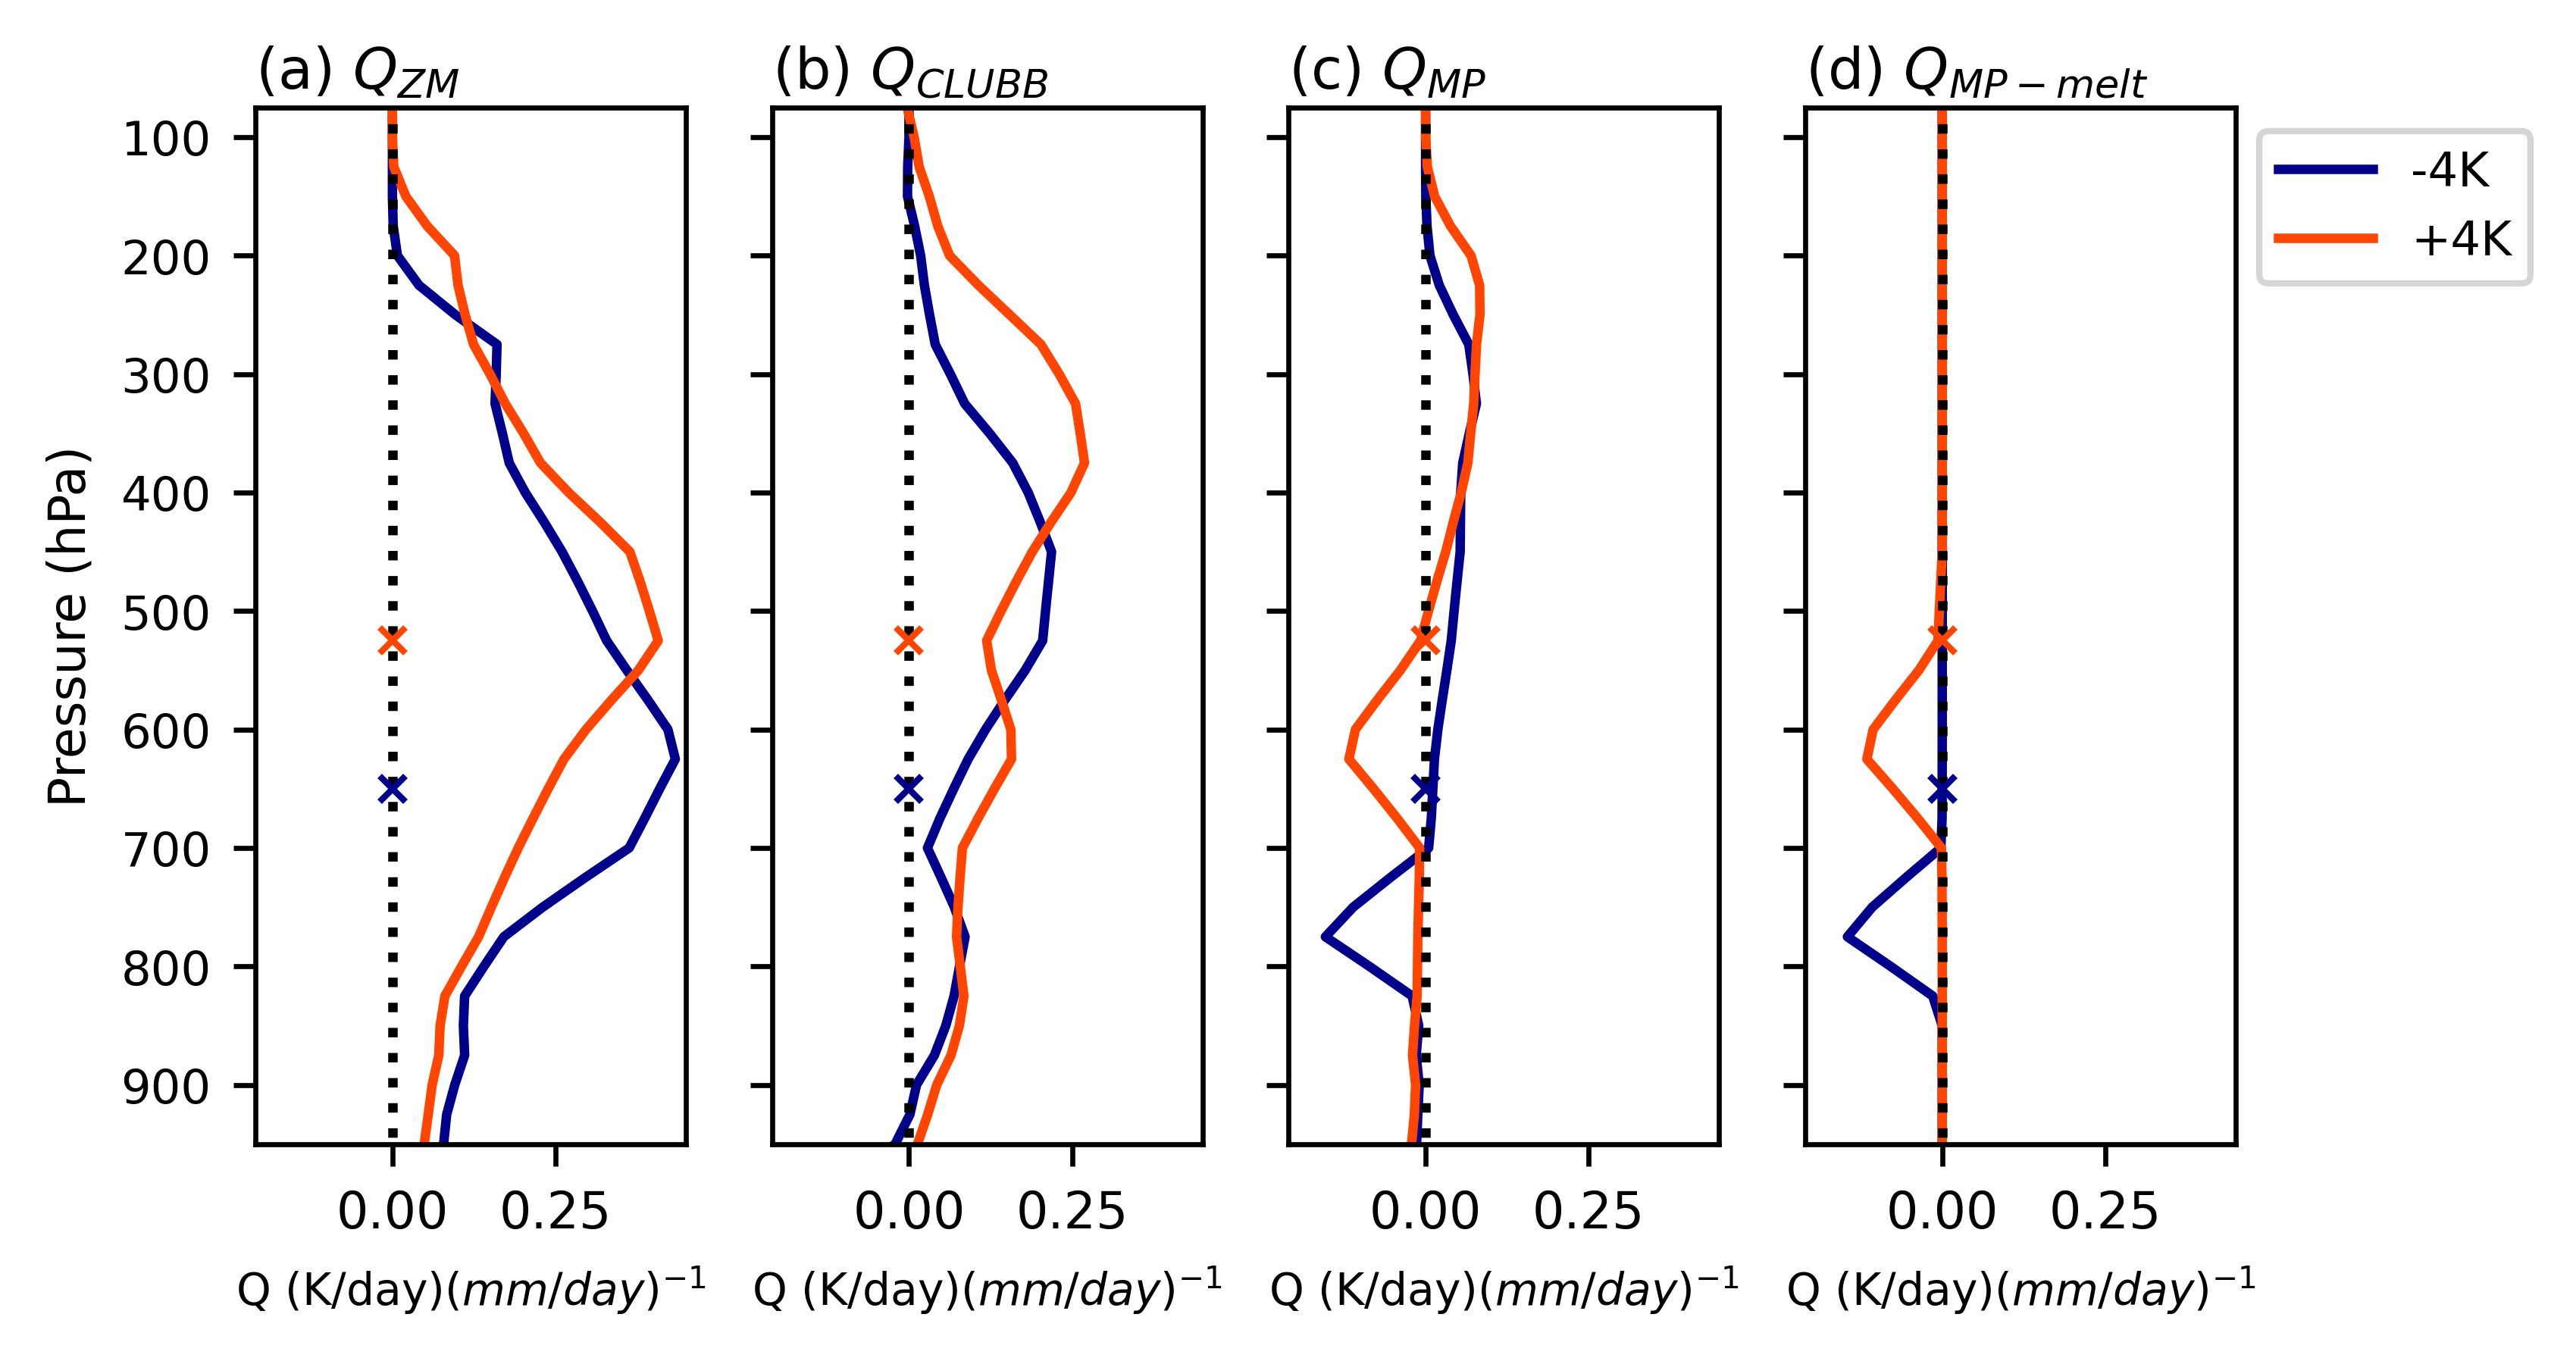

In [86]:
###############################
# Fig. 14: Plot 4 figures together
################################
mark_melting_level=1
for icase in range(0,3):
    if icase == 0:
        ilev_melt = np.zeros([3]).astype('int')
    ilev_melt[icase] = int(np.argwhere(np.abs(Tm[:,icase])==np.min(np.abs(Tm[:,icase]))).squeeze())
print(plev_m[ilev_melt])

title = list(['(a) $Q_{ZM}$','(b) $Q_{CLUBB}$','(c) $Q_{MP}$','(d) $Q_{MP-melt}$'])
#'(b) $Q_{MP}$' $Q_{CLUBB}$
#'Q_CLUBB_lag0_plev','Q_MP_lag0_plev',
xlabel_list = list(['Q (K/day)$(mm/day)^{-1}$','Q (K/day)$(mm/day)^{-1}$',\
                   'Q (K/day)$(mm/day)^{-1}$','Q (K/day)$(mm/day)^{-1}$'])
font = 8
fig,axes = plt.subplots(1,4,figsize=(6.5, 3),dpi=600)
plt.subplots_adjust(left=0.15,right=0.82,top=0.91,bottom=0.15,wspace=0.2)
plt.rcParams.update({'font.size': font})
zero = np.zeros([nlev])
vname = list(['Q_ZM_lag0_plev','Q_CLUBB_lag0_plev','Q_MP_lag0_plev','MELTSDT_lag0_plev'])#'Tm_10SN'])
for iplt in range(0,4):
    plt.subplot(1,4,iplt+1)
    ax = plt.gca()
    V = globals()[vname[iplt]]
    V = V/pr_var

    for icase in range(0,3):
        if icase == 1:
            continue
        plt.plot(V[:,icase], plev, color=color_list[icase])

    plt.plot(zero, plev,'k:')
    plt.tick_params(bottom=True,top=False,left=True,right=False)
    plt.ylim([75, 950]) 
    plt.yticks(np.arange(100,1000,100),fontsize=7.5)
    if iplt == 3:
        #ax.legend(['-4K','CTL','+4K'],bbox_to_anchor=(1, 1), loc='upper left',fontsize=7.5)
        ax.legend(['-4K','+4K'],bbox_to_anchor=(1, 1), loc='upper left',fontsize=7.5)
    plt.gca().invert_yaxis()
    plt.title(title[iplt], pad=3, loc='left',fontsize=9)
    if iplt == 0:
        plt.ylabel('Pressure (hPa)')
        plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
    else:
        plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
    plt.xlabel(xlabel_list[iplt],fontsize=7)
    #if iplt == 0 or iplt == 1:
    #    plt.xlim([-0.02,0.4])
    #else:
    plt.xlim([-0.21,0.45])
    
    # Mark melting level:
    if mark_melting_level == 1:
        for icase in range(0,3):
            if icase == 1:
                continue
            plt.plot( 0, plev_m[ilev_melt[icase]], color=color_list[icase], marker='x',markersize=4)
    #
plt.savefig(figdir+'Fig.4_Q_each_physics.png',dpi=600)
plt.show()